In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

import sklearn
sklearn.set_config(display='text')
from sklearn import datasets
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.utils import to_categorical # 원-핫 인코딩을 사용하기 위해 import 한다.
from tensorflow.keras.models import Sequential # layer들을 일렬로 차례대로 쌓아올리는 순차적 모델 구조를 생성하기 위해 import 한다.
from tensorflow.keras.layers import Dense # 신경망의 가장 기본이 되는 Dense Layer(Fully Connected, 완전 연결층, 밀집층)를 생성하기 위해 import 한다.
from tensorflow.keras.layers import BatchNormalization # 배치 정규화 layer를 생성하기 위해 import 한다.
from tensorflow.keras.layers import Activation # layer의 연산 결과에 활성화 함수를 적용하기 위해서 import 한다.

분류 신경망을 이용해서 와인 종류를 분류하는 모델을 만든어 본다.

분류 신경망에 사용할 데이터 준비

In [14]:
# 데이터 불러오기
raw_data = datasets.load_wine() # 사이킷런이 제공하는 와인 데이터를 불러온다.

# 피처, 레이블 저장
xData = raw_data.data # 피쳐 데이터를 저장한다.
yData = raw_data.target # 피쳐 데이터에 따른 레이블을 저장한다.
print(xData.shape, yData.shape)
# 총 13개의 피쳐가 있고, 이는 신경망을 생성할 때 사용된다.

# 레이블 종류 확인
# 레이블의 종류를 확인함으로써 분류 문제인지 아니면 회귀 문제인지 파악할 수 잇고, 분류 문제라면 몇 가지 클래스로 구분되는 지 알 수 있다.
print(len(set(yData)))
print(set(yData))

# 레이블 데이터 원-핫 인코딩, 분류 문제에만 사용하고 회귀 문제에는 사용하면 안된다.
# to_categorical() 함수는 데이터를 표현할 때 전부 0으로 표현하고 그중 1개만 1로 표현하는 원-핫 인코딩을 실행한다.
yData_onehot = to_categorical(yData)
print(yData_onehot)

# 학습 데이터와 테스트 데이터로 분할
x_train, x_test, y_train, y_test = train_test_split(xData, yData_onehot, random_state=0)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(178, 13) (178,)
3
{0, 1, 2}
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]

시퀀스를 사용하는 분류 신경망 생성

In [3]:
# 분류 신경망 모델을 학습하기 위해서 입력되는 데이터(피쳐) 개수와 출력되는 데이터(클래스) 개수를 저장한다.
n = x_train.shape[1]
c = len(set(yData))
print(f'입력 데이터 1건의 차원: {n}, 출력되는 클래스 개수: {c}')

입력 데이터 1건의 차원: 13, 출력되는 클래스 개수: 3


In [4]:
# Sequential 객체 선언 후 Sequential 모델에 add() 메소드로 레이어를 추가해서 신경망을 만든다.
model = Sequential() # 시퀀스를 사용하는 신경망을 만든다.

# 입력 레이어를 만든다.
# input_dim 속성으로 입력 데이터 1건의 차원(피쳐의 개수), units 속성으로 레이어의 출력 차원을 지정한다.
# input_dim 속성은 1차원 형태의 피쳐의 차원을 지정한다. 2차원 이미지는 input_shape 속성을 사용한다. input_dim, input_shape 속성은 입력 레이어에만 사용한다.
# units 속성은 이 층이 다음 층으로 내보낼 출력 데이터의 차원을 지정한다. 뉴런의 개수
# model.add(Dense(input_dim=n, units=20)) # 신경망 모델에 입력 레이어를 추가한다.
# model.add(Activation('relu')) # 신경망 모델의 출력에 relu 활성화 함수 레이어를 추가한다.
# Activation 레이어를 사용하지 않고 Dence 레이어의 activation 속성을 이용해서 활성화 함수를 지정할 수 있다.
model.add(Dense(input_dim=n, units=20, activation='relu'))

# 신경망 모델에 배치 정규화 레이어를 추가한다.
model.add(BatchNormalization())

# 출력 레이어를 만든다.
# 출력 레이어는 구분해야 할 클래스의 개수 만큼 units 속성을 지정한다.
# model.add(Dense(units=c)) # 신경망 모델에 출력 레이어를 추가한다.
# model.add(Activation('softmax')) # 신경망 모델의 출력에 softmax 활성화 함수 레이어를 추가한다.
model.add(Dense(units=c, activation='softmax'))

# Dense 레이어의 Param은 '(입력 개수 + 바이어스) * 출력 개수'로 계산되고 바이어스는 레이어당 1개 이다.
# BatchNormalization 레이어의 Param은 '입력 개수 * 4'로 계산된다.
model.summary() # 신경망 모델의 구조를 확인한다.


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 20)                280       
                                                                 
 batch_normalization (Batch  (None, 20)                80        
 Normalization)                                                  
                                                                 
 dense_1 (Dense)             (None, 3)                 63        
                                                                 
Total params: 423 (1.65 KB)
Trainable params: 383 (1.50 KB)
Non-trainable params: 40 (160.00 Byte)
_________________________________________________________________


분류 신경망 모델 컴파일

compile() 메소드로 생성한 신경망 모델을 컴파일 한다. 모델을 실행 가능한 상태로 만든다.  
loss 속성에 손실(비용, 오차) 함수를 지정할 때 이진 분류(`binary_crossentropy`), 다중 분류(`categorical_crossentropy`)를 지정한다.  
optimizer 속성에 최적화 함수(일반적으로 `adam`)를 지정한다.  
metrics 속성에 평가 기준(일반적으로 `accuracy`)을 지정한다.

In [5]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

분류 신경망 모델 학습

fit() 메소드의 인수로 학습 데이터(x_train)와 학습 데이터에 따른 레이블을 원-핫 인코딩한 데이터(y_train)를 넘기고 학습 횟수(epochs)를 지정해서 모델을 학습시킨다.  
x: 학습 데이터  
y: 학습 데이터에 따른 레이블을 원-핫 인코딩한 데이터  
batch_size: 하나의 미니 배치에 속하는 데이터 개수  
epoch: 전체 학습 횟수, 전체 학습 데이터셋 전체가 신경망을 통과하는 횟수

In [6]:
result = model.fit(x_train, y_train, epochs=50)

Epoch 1/50


5/5 [==============================] - 1s 6ms/step - loss: 1.1115 - accuracy: 0.5263
Epoch 2/50
5/5 [==============================] - 0s 5ms/step - loss: 1.0602 - accuracy: 0.5338
Epoch 3/50
5/5 [==============================] - 0s 3ms/step - loss: 1.0404 - accuracy: 0.5414
Epoch 4/50
5/5 [==============================] - 0s 5ms/step - loss: 0.9861 - accuracy: 0.5414
Epoch 5/50
5/5 [==============================] - 0s 3ms/step - loss: 0.9486 - accuracy: 0.5564
Epoch 6/50
5/5 [==============================] - 0s 2ms/step - loss: 0.9335 - accuracy: 0.5338
Epoch 7/50
5/5 [==============================] - 0s 4ms/step - loss: 0.8969 - accuracy: 0.5414
Epoch 8/50
5/5 [==============================] - 0s 2ms/step - loss: 0.8784 - accuracy: 0.5489
Epoch 9/50
5/5 [==============================] - 0s 3ms/step - loss: 0.8573 - accuracy: 0.5338
Epoch 10/50
5/5 [==============================] - 0s 3ms/step - loss: 0.8383 - accuracy: 0.5188
Epoch 11/50
5/5 [====================

In [7]:
# 모델 epoch 단계별로 오차와 정확도 확인
for loss, accuracy in zip(result.history['loss'], result.history['accuracy']):
    print('loss: {:6.4f} - accuracy: {:6.4f}'.format(loss, accuracy))

loss: 1.1115 - accuracy: 0.5263
loss: 1.0602 - accuracy: 0.5338
loss: 1.0404 - accuracy: 0.5414
loss: 0.9861 - accuracy: 0.5414
loss: 0.9486 - accuracy: 0.5564
loss: 0.9335 - accuracy: 0.5338
loss: 0.8969 - accuracy: 0.5414
loss: 0.8784 - accuracy: 0.5489
loss: 0.8573 - accuracy: 0.5338
loss: 0.8383 - accuracy: 0.5188
loss: 0.8144 - accuracy: 0.5188
loss: 0.8141 - accuracy: 0.4812
loss: 0.7817 - accuracy: 0.4737
loss: 0.7852 - accuracy: 0.5188
loss: 0.7567 - accuracy: 0.5865
loss: 0.7609 - accuracy: 0.6241
loss: 0.7698 - accuracy: 0.6241
loss: 0.7524 - accuracy: 0.6241
loss: 0.7620 - accuracy: 0.6165
loss: 0.7397 - accuracy: 0.6316
loss: 0.7330 - accuracy: 0.6165
loss: 0.7248 - accuracy: 0.6165
loss: 0.7126 - accuracy: 0.6165
loss: 0.7002 - accuracy: 0.6316
loss: 0.7227 - accuracy: 0.6241
loss: 0.6752 - accuracy: 0.6241
loss: 0.6946 - accuracy: 0.6391
loss: 0.6580 - accuracy: 0.6541
loss: 0.6417 - accuracy: 0.6767
loss: 0.6478 - accuracy: 0.6917
loss: 0.6603 - accuracy: 0.6992
loss: 0.

In [8]:
# 모델의 최종 오차와 정확도 확인
print(result.history['loss'][-1])
print(result.history['accuracy'][-1])

0.43558162450790405
0.932330846786499


분류 신경망 모델 테스트

evaluate() 메소드의 인수로 테스트 데이터(x_test)와 테스트 데이터에 따른 레이블을 원-핫 인코딩한 데이터(y_test)를 넘겨서 학습된 신경망을 평가한다.

In [9]:
print(model.evaluate(x_test, y_test))

2/2 [==============================] - 0s 8ms/step - loss: 1.0512 - accuracy: 0.4444
[1.0512350797653198, 0.4444444477558136]


정확도 및 손실 정도 시각화

In [10]:
epoch = np.arange(1, 51)
accuracy = result.history['accuracy']
loss = result.history['loss']

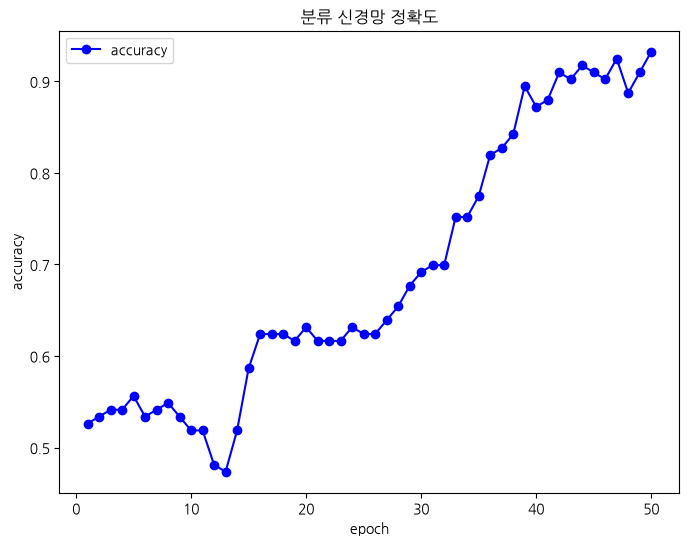

In [11]:
# 학습 정확도 시각화
plt.figure(figsize=(8, 6))
plt.plot(epoch, accuracy, 'bo-', label='accuracy')
plt.title('분류 신경망 정확도')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()

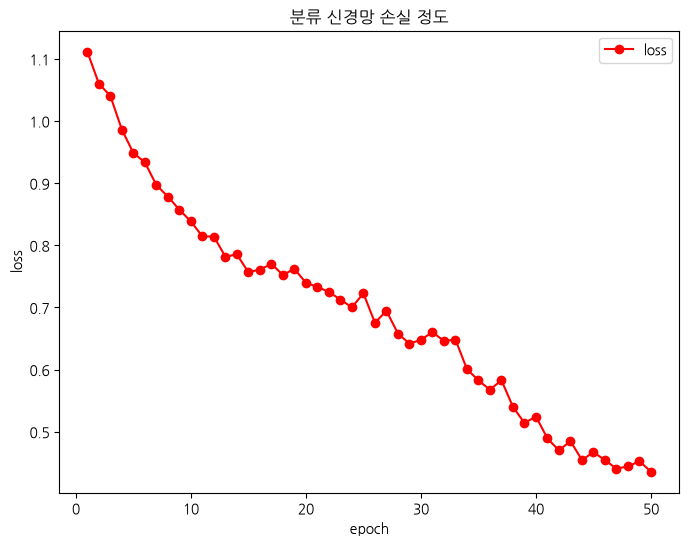

In [12]:
# 손실 정도 시각화
plt.figure(figsize=(8, 6))
plt.plot(epoch, loss, 'ro-', label='loss')
plt.title('분류 신경망 손실 정도')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

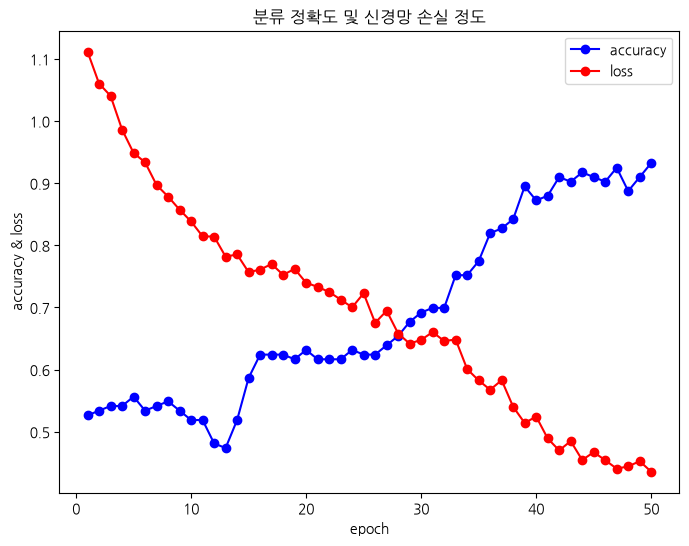

In [13]:
plt.figure(figsize=(8, 6))
plt.plot(epoch, accuracy, 'bo-', label='accuracy')
plt.plot(epoch, loss, 'ro-', label='loss')
plt.title('분류 정확도 및 신경망 손실 정도')
plt.xlabel('epoch')
plt.ylabel('accuracy & loss')
plt.legend()
plt.show()